**Task 1**  
NAIP feature extraction:  

*visible appearance of shrubs:*
* *texture*
* *color differences* - complete via various gradients 
* *local boundaries* - complete via gradient, canny edge, 
* *surrounding land-cover context*
* *NIR-based vegetation signal*

*Bands to process - all bands will be processed individually unless it's faster to compute a 3d convolution:*
* RGB
* NIR 

Derived features
* *NDVI*
* *local variance*
* **entropy**
* **edge density**
* *local binary patterns*
* **GLCM might be more manageable with GPU libraries, but I had trouble getting this to work locally. It either crashed or it took significant time to process a chunked input (i.e. multiple minutes for <1% of total computation required, albeit with a CPU.)** *GLCM-style texture summaries* $\rightarrow$ GLCM is too slow since it performs sliding window over the entire image. Using local binary pattern as an approximation. LBP is relatively slow, but it is at least feasible to compute.
* **gradient magnitude**

**Task 2**  
Recalculate above features, but with different kernel sizes (e.g. 5x5, 7x7, etc.)

**Plan 1**  
Extract all features noting that the overhead makes it possible for trees to cover shrubs, but this itself should be a useful feature.  




In [2]:
# TODO - read in NAIP file and then you can perform all image processing
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from typing import List
from pathlib import Path

naip_fp = Path("naip_sample_data") / "m_3912038_ne_10_060_20220720.tif"

rgb_channels = [1,2,3]
nir_channel = [4]
with rasterio.open(naip_fp) as src:
    print(type(src))
    # rgb = get_naip_channels(src, rgb_channels)
    # plt.imshow(rgb)
    # plt.axis("off")
    # plt.show()

    # nir = get_naip_channels(src, nir_channel)
    # plt.imshow(nir)
    # plt.axis("off")
    # plt.show()

<class 'rasterio.io.DatasetReader'>


In [3]:
import os

naip_save_dir = Path("naip_channel_processed")
if not os.path.exists(naip_save_dir):
    print("Created .../features/naip_channel_processed directory")
    os.mkdir(naip_save_dir, exist_ok=False)

In [4]:
def extract_color_channels(src: rasterio.io.DatasetReader, channels: List):
    """
    Returns rgb color channels from NAIP input image
    
    Args:
        src - 2d array from result of `with rasterio.open(naip_fp) as src: ...`
    """
    scale = 1
    preview = src.read(
        indexes=channels, 
        out_shape=(len(channels), src.height // scale, src.width // scale),
        resampling=rasterio.enums.Resampling.bilinear
    ).astype(np.float32)

    channel = np.transpose(preview, (1,2,0))
    clamp = np.clip(channel / (np.nanmax(channel) + 1e-12), 0, 1)

    return clamp

In [5]:
def get_all_bands(src: rasterio.io.DatasetReader):
    channels = list(np.arange(1, src.count+1))

    bands = list()
    all_bands = extract_color_channels(src, channels)
    for band in range(src.count):
        bands.append(all_bands[:,:,band])

    return bands

In [6]:
def get_naip_info(src):
    info = dict()

    info["dims"] = (src.width, src.height)
    info["crs"] = src.crs
    info["num_bands"] = src.count
    info["band_dtypes"] = src.dtypes
    info["bounding_box"] = src.bounds
    info["res"] = src.res

    return info

In [7]:
fname = "m_3912038_ne_10_060_20220720.tif"
naip_sample_dir = Path("naip_sample_data")
naip_save_dir = Path("naip_channel_processed")

with rasterio.open(naip_sample_dir / fname) as src:
    bands = get_all_bands(src)

    for band in bands:
        print(band.shape)
    # fname = fname.split(".tif")[0]
    # np.save(naip_save_dir / fname, bands)

(12500, 9980)
(12500, 9980)
(12500, 9980)
(12500, 9980)


In [8]:
band.shape

(12500, 9980)

In [9]:
src

<closed DatasetReader name='naip_sample_data\m_3912038_ne_10_060_20220720.tif' mode='r'>

In [10]:
def get_gradient_kernels():
    lap_adjacent = np.array([
        [0,1,0],
        [1,-4,1],
        [0,1,0] 
    ])

    lap_surround = np.array([
        [1,1,1],
        [1,-8,1],
        [1,1,1]
    ])

    sobel_x = np.array([
        [-1,0,1],
        [-2,0,2],
        [-1,0,1]
    ])

    sobel_y = np.array([
        [-1,-2,-1],
        [0,0,0],
        [1,2,1],
    ])

    scharr_x = np.array([
        [-3,0,3],
        [-10,0,10],
        [-3,0,3]
    ])

    scharr_y = np.array([
        [-3,-10,-3],
        [0,0,0],
        [3,10,3],
    ])

    prewitt_x = np.array([
        [-1,0,1],
        [-1,0,1],
        [-1,0,1]
    ])

    prewitt_y = np.array([
        [-1,-1,-1],
        [0,0,0],
        [1,1,1]
    ])

    roberts_positive = np.array([
        [1,0],
        [0,-1]
    ])

    roberts_negative = np.array([
        [0,1],
        [-1,0]
    ])

    gradient_kernels = [
        lap_adjacent,
        lap_surround,
        sobel_x,
        sobel_y,
        scharr_x,
        scharr_y,
        prewitt_x,
        prewitt_y,
        roberts_positive,
        roberts_negative
    ]

    return gradient_kernels



In [ ]:
from scipy.signal import convolve2d
from skimage import feature
from scipy.ndimage import morphological_gradient

def get_color_diff(band, kernel):
    """
    Retrieves the color difference for a single band by applying the specified kernel.

    Args:
        band - 2d array of pixels
        kernel - kernel for convolution
    """
    color_diff = convolve2d(band, kernel, mode="same") .astype(int)

    # plotting color diff is not useful, but patterns can be learned from it
    return color_diff


with rasterio.open(naip_sample_dir / fname) as src:
    bands = get_all_bands(src)

    output_feats = list([] for _ in range(src.count))

    gradient_kernels = get_gradient_kernels()
    std_range = list(range(1,6)) # higher stds don't have visually noticeable boundaries
    min_kernel_radius, max_kernel_radius = 2, 5 # distance from center to border, not including the center cell.


    # individual bands can be effectively be treated as grayscale
    for i, band in enumerate(bands[:1]):
        continue
        # neighbor differences
        for kernel in gradient_kernels:
            adj_diff = get_color_diff(band, kernel)
            output_feats[i].append(adj_diff)
        
        # boundary detection
        for std in std_range:
            boundaries = feature.canny(band.astype(float), sigma=std)
            output_feats[i].append(boundaries)

        for side_length in range(1+min_kernel_radius, 1+max_kernel_radius*2, 2):
            morph_grad = morphological_gradient(band, size=(side_length, side_length))
            output_feats[i].append(morph_grad)

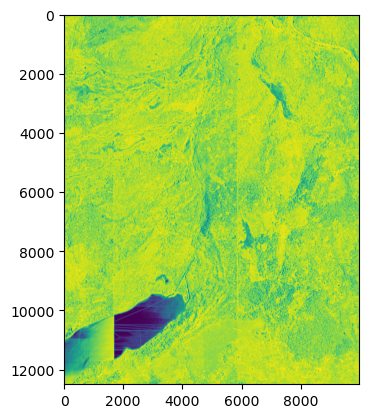

In [38]:
import numpy as np
from skimage.filters.rank import entropy
from skimage.morphology import square, disk

def get_entropy_feature(band, shape="disk", neighborhood_size=25, bins=256):
    """
    Calculates the local Shannon Entropy (information content) of a 2D array.
    """
    # 1. Handle perfectly flat chunks (e.g., pure black NoData borders)
    # If the max and min are the same, there is zero information.
    b_min, b_max = band.min(), band.max()
    if b_max == b_min:
        return np.zeros_like(band, dtype=np.float32)
        
    # 2. The Quantization Step
    # Squeeze the continuous floating-point values into discrete integer bins.
    # We use uint16 just in case you want to test more than 256 bins.
    quantized = np.floor((bins - 1) * (band - b_min) / (b_max - b_min)).astype(np.uint16)
    
    # 3. Define the Sliding Window Shape
    # square(5) creates a standard 5x5 window.
    # disk(3) creates a circular window with a radius of 3 (great for natural textures).
    if shape == "disk":
        footprint = disk(neighborhood_size)
    else:
        footprint = square(neighborhood_size)
    
    # 4. Calculate the Entropy
    # This runs through an optimized C-loop and returns the entropy in 'bits'
    entropy_map = entropy(quantized, footprint)
    
    return entropy_map

# plt.imshow(band)
# plt.show()

res = get_entropy_feature(band)
plt.imshow(res)
plt.show()

In [ ]:
import numpy as np
from scipy.ndimage import uniform_filter

def get_first_four_moments(band, size=5, excess=True):
    """
    Calculates a dense Kurtosis feature map using fully vectorized O(1) convolutions.
    """
    x = band.astype(np.float32)
    
    # 1. Calculate the first four raw moments
    e_x = uniform_filter(x, size=size)
    e_x2 = uniform_filter(x**2, size=size)
    e_x3 = uniform_filter(x**3, size=size)
    e_x4 = uniform_filter(x**4, size=size)
    
    # 2. Calculate Variance (Second central moment)
    variance = e_x2 - (e_x**2)
    
    # Prevent division by zero and floating point negative zeros
    variance = np.clip(variance, a_min=1e-8, a_max=None) 

    mu_3 = e_x3 - 3 * e_x * e_x2 + 2 * (e_x**3)
    skewness = mu_3 / (variance ** 1.5)

    # 3. Calculate the Fourth central moment (mu_4)
    # Using the expanded binomial formula
    mu_4 = e_x4 - 4 * e_x3 * e_x + 6 * e_x2 * (e_x**2) - 3 * (e_x**4)
    
    # 4. Calculate standard Pearson Kurtosis
    kurtosis = mu_4 / (variance ** 2)
    
    # 5. Optional: Excess Kurtosis
    # A perfectly normal distribution has a kurtosis of 3. 
    # Subtracting 3 centers the "normal" baseline at 0.
    if excess:
        kurtosis = kurtosis - 3.0
        
    return e_x, variance, skewness, kurtosis

In [32]:
import numpy as np
from scipy.ndimage import grey_opening, grey_closing

def get_granulometry_features(band, scales=[3, 5, 7, 11, 15]):
    """
    Extracts a Differential Morphological Profile (Granulometry) 
    to measure the physical size distribution of local textures.
    """
    features = []
    
    # We track the "previous" state of the image to find the difference.
    # We start with the raw band.
    prev_opened = band.astype(np.float32)
    prev_closed = band.astype(np.float32)

    for s in scales:
        # --- Process Bright Objects (Opening) ---
        opened = grey_opening(prev_opened, size=(s, s))
        # The feature is the "residue": what was destroyed at this exact scale?
        bright_residue = prev_opened - opened
        features.append(bright_residue)
        # Update the state for the next, larger iteration
        prev_opened = opened
        
        # --- Process Dark Objects (Closing) ---
        closed = grey_closing(prev_closed, size=(s, s))
        # For closing, the closed image is brighter than the original, 
        # so we subtract in reverse to get a positive residue.
        dark_residue = closed - prev_closed
        features.append(dark_residue)
        prev_closed = closed

    # Stack into a dense 3D feature cube: (height, width, number_of_features)
    # If you pass 5 scales, this returns 10 net-new feature layers 
    # (5 for bright object sizes, 5 for dark object sizes).
    return np.dstack(features)

res = get_granulometry_features(band)
res.shape

(12500, 9980, 10)

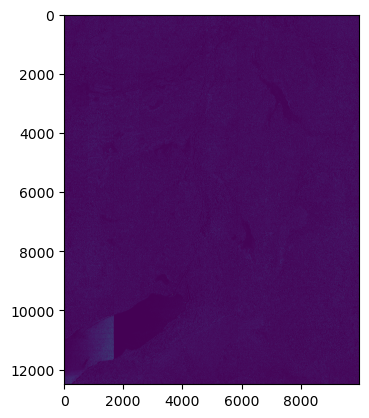

In [33]:
plt.imshow(res[...,0])

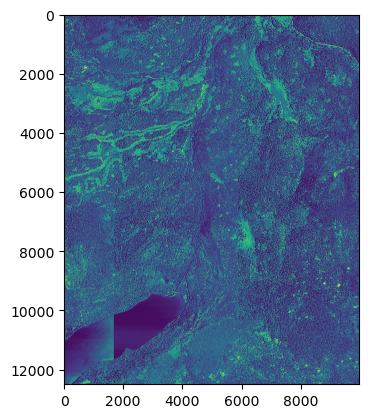

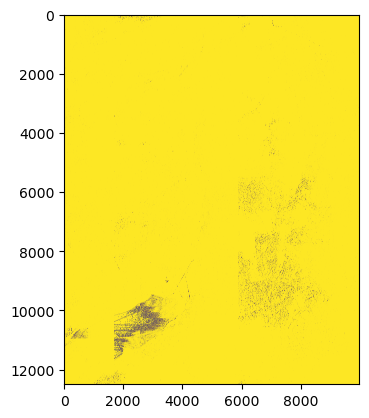

In [30]:
import numpy as np
from scipy.ndimage import maximum_filter, minimum_filter

def get_fractal_dimension_map(band, scales=[3, 5, 7, 9]):
    """
    Calculates a dense Fractal Dimension map using a sliding window.
    Bypasses spatial loops by using vectorized morphological filters.
    """
    band = band.astype(np.float32)
    
    # Store the log(Number of Boxes) maps for each scale
    log_N_stack = []
    
    for s in scales:
        # 1. The "Convolution" equivalent for Max and Min
        # This runs highly optimized C-code under the hood
        local_max = maximum_filter(band, size=s)
        local_min = minimum_filter(band, size=s)
        
        # 2. Calculate the local 3D box count
        # (Adding 1 ensures perfectly flat areas evaluate to 1 box, 
        # preventing np.log(0) which throws an error)
        n_boxes = np.ceil((local_max - local_min) / s) + 1
        
        log_N_stack.append(np.log(n_boxes))
        
    # Stack into a 3D volume: (height, width, number_of_scales)
    Y = np.dstack(log_N_stack)
    
    # X values are the log of the inverse scale: log(1/s)
    X = np.log(1.0 / np.array(scales))
    
    # 3. Vectorized Linear Regression down the Z-axis
    # Formula: Slope = Sum((x - mean_x) * (y - mean_y)) / Sum((x - mean_x)^2)
    
    mean_X = np.mean(X)
    # keepdims=True is crucial so we can broadcast the subtraction against the 3D volume
    mean_Y = np.mean(Y, axis=2, keepdims=True)
    
    numerator = np.sum((X - mean_X) * (Y - mean_Y), axis=2)
    denominator = np.sum((X - mean_X)**2)
    
    # Prevent division by zero (only happens if only 1 scale is provided)
    if denominator == 0:
        return np.zeros_like(band)
        
    # The slope of the log-log plot is the local Fractal Dimension
    fractal_dimension_map = numerator / denominator
    
    # Optional: Flat areas might evaluate to 0 slope because n_boxes is always 1. 
    # A true flat 2D plane has an FD of 2.0. You can re-normalize flat areas if needed.
    # fractal_dimension_map[fractal_dimension_map == 0] = 2.0
    
    return fractal_dimension_map

plt.imshow(band)
plt.show()

res = get_fractal_dimension_map(band)
plt.imshow(res)
plt.show()

In [27]:
# frequency domain
import pywt
import numpy as np
import cv2

def get_wavelet_features(band, wavelet_type='db2', level=2):
    """
    Extracts multi-level texture features using a 2D Wavelet Transform.
    """
    # wavedec2 performs the multi-level 2D Discrete Wavelet Transform
    # It returns a list: [LL_final, (HL_level_n, LH_level_n, HH_level_n), ..., (HL_level_1, LH_level_1, HH_level_1)]
    coeffs = pywt.wavedec2(band, wavelet=wavelet_type, level=level)
    
    # Extract the Approximation (blur) from the deepest level
    LL = coeffs[0]
    
    # Extract the details from Level 1 (Micro-texture)
    HL_1, LH_1, HH_1 = coeffs[-1]
    
    # Extract the details from Level 2 (Macro-texture)
    HL_2, LH_2, HH_2 = coeffs[-2]
    
    # Note: The outputs of DWT are physically smaller than the original image 
    # (Level 1 is half size, Level 2 is quarter size). 
    # To use these as pixel-by-pixel ML features, you must resize them back 
    # to the original band shape using bilinear or nearest-neighbor interpolation.
    
    original_shape = (band.shape[1], band.shape[0]) # (width, height)
    
    features = [
        cv2.resize(HL_1, original_shape, interpolation=cv2.INTER_LINEAR),
        cv2.resize(LH_1, original_shape, interpolation=cv2.INTER_LINEAR),
        cv2.resize(HH_1, original_shape, interpolation=cv2.INTER_LINEAR),
        cv2.resize(HL_2, original_shape, interpolation=cv2.INTER_LINEAR),
        cv2.resize(LH_2, original_shape, interpolation=cv2.INTER_LINEAR),
        cv2.resize(HH_2, original_shape, interpolation=cv2.INTER_LINEAR)
    ]
    
    return np.dstack(features)

# plt.imshow(band)
# plt.show()

res = get_wavelet_features(band)
res.shape

(12500, 9980, 6)

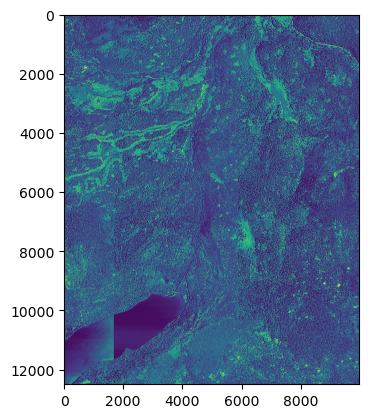

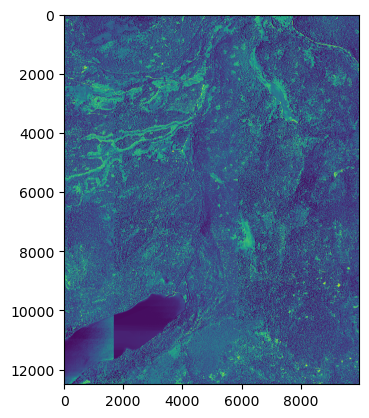

In [ ]:
# frequency domain
import numpy as np
from scipy.signal import fftconvolve
from skimage.filters import gabor_kernel

def fast_cpu_gabor(band, frequency, theta):
    # 1. Generate the kernel
    kernel = np.real(gabor_kernel(frequency, theta=theta))
    
    # 2. Use Scipy's FFT convolution instead of spatial convolution
    filtered_cpu = fftconvolve(band, kernel, mode='same')
    
    return filtered_cpu

plt.imshow(band)
plt.show()

res = fast_cpu_gabor(band, 1, 0)
plt.imshow(res)
plt.show()

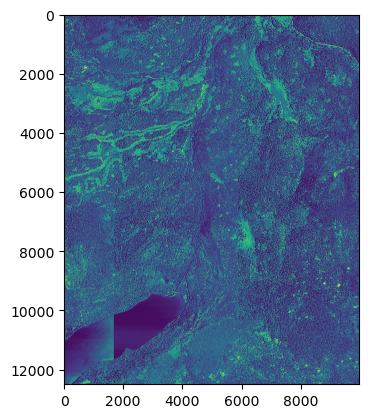

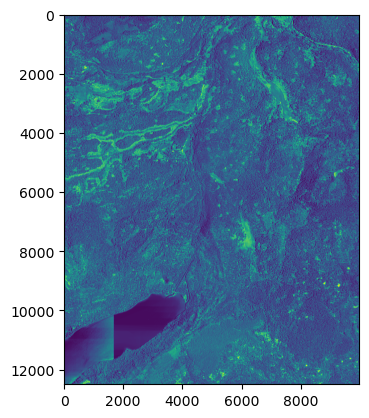

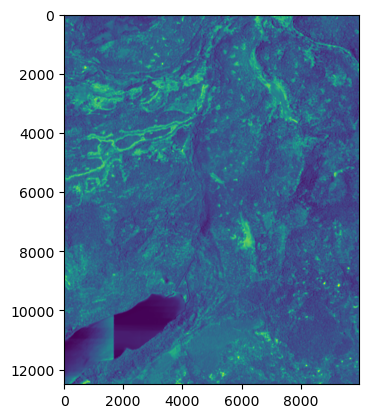

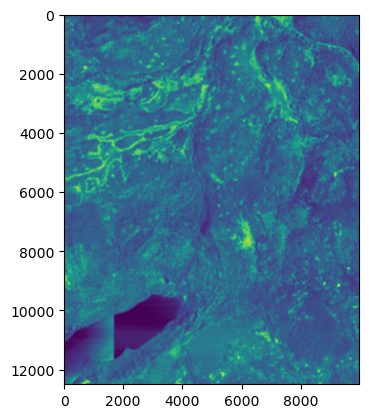

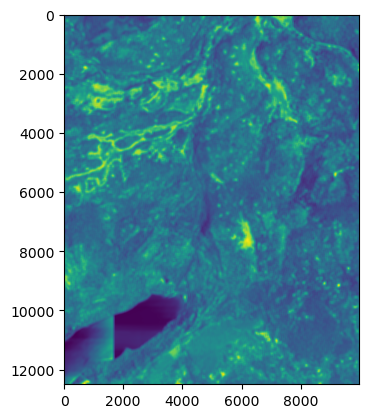

In [ ]:
from scipy.ndimage import uniform_filter

def get_uniform_blur(band, neighborhood_size):
    blurred = uniform_filter(band.astype(float), size=neighborhood_size)
    
    return blurred

plt.imshow(band)
plt.show()
for blur_length in (range(1,5)):
    plt.imshow(get_uniform_blur(band, neighborhood_size=1+25*blur_length))
    plt.show()

In [ ]:
from skimage.feature import local_binary_pattern

def get_fast_lbp_texture(band, radius=3):
    # Number of points to consider around the center pixel
    n_points = 8 * radius # 8 approximates the actual ring size for larger rings
    
    # 'uniform' method groups similar patterns together, making it highly 
    # effective for ML models (reduces the feature complexity)
    lbp_feature_map = local_binary_pattern(band, n_points, radius, method='uniform')
    
    return lbp_feature_map

# derived features
for radius in [1,3,5]:
    lbp = get_fast_lbp_texture(band, radius=radius)

c:\Users\seani\miniforge3\envs\res_pipeline\Lib\site-packages\skimage\feature\texture.py:353: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


In [ ]:
from scipy.ndimage import uniform_filter

def get_context_feature(band, neighborhood_size=51):
    # A uniform filter is incredibly optimized in scipy. 
    # It calculates the local mean over the specified massive window size
    # in almost O(1) time per pixel, regardless of how large the window is.
    context_map = uniform_filter(band.astype(float), size=neighborhood_size)
    
    return context_map

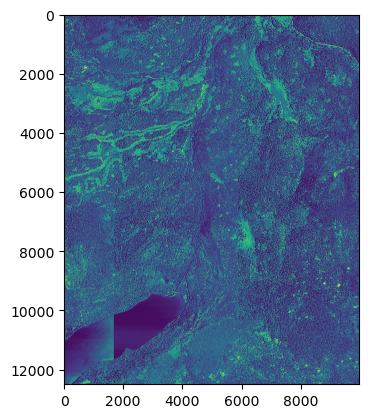

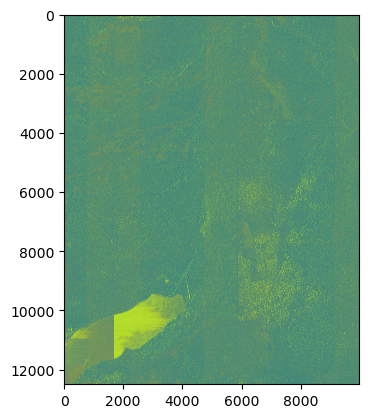

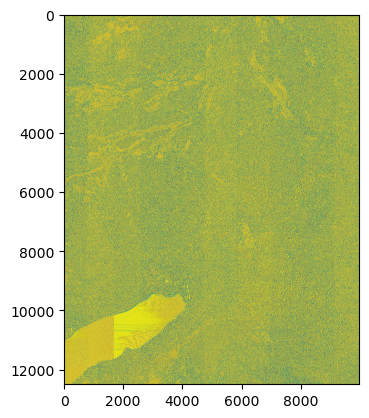

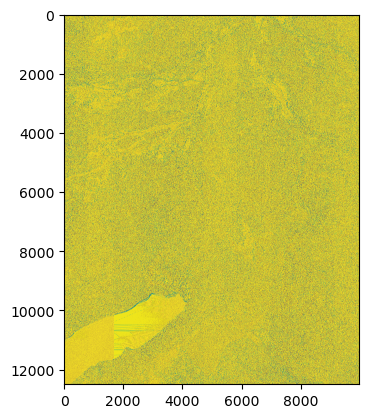

In [ ]:
plt.imshow(band)
plt.show()

for radius in [1,3,5]:
    lbp = get_fast_lbp_texture(band, radius=radius)
    plt.imshow(lbp)
    plt.show()

In [ ]:
def get_ndvi(red_band, nir_band):
    eps = 1e-12
    return (nir_band - red_band) / (nir_band + red_band + eps)

def get_vari(red_band, green_band, blue_band):
    num, denom = green_band - red_band, green_band + red_band - blue_band
    if denom == 0:
        return 0
    return num / denom

In [ ]:
band.shape

(12500, 9980)

In [ ]:
import numpy as np

min_kernel_radius, max_kernel_radius = 1, 5
for side_length in range(1+2*min_kernel_radius, 1+max_kernel_radius*2, 2):
    print()
    morph_grad = morphological_gradient(band, size=(side_length, side_length))
    output_feats[i].append(morph_grad)

In [ ]:
def process_band(band):
    """
    Perform all band processing. Bands can be processed individually as they are only comparable to bands of the same input.
    """
    pass

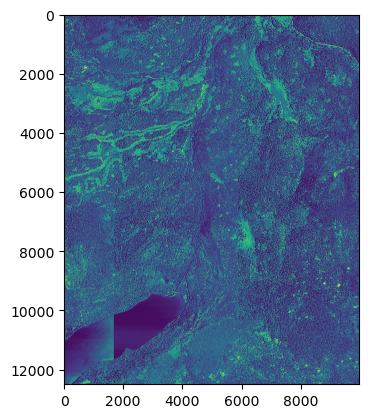

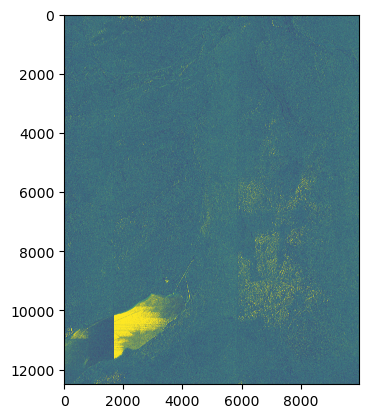

In [ ]:
kirsch_masks = [
    np.array([[-3, -3, 5], [-3, 0, 5], [-3, -3, 5]]), # 0: East
    np.array([[-3, 5, 5], [-3, 0, 5], [-3, -3, -3]]), # 1: North-East
    np.array([[5, 5, 5], [-3, 0, -3], [-3, -3, -3]]), # 2: North
    np.array([[5, 5, -3], [5, 0, -3], [-3, -3, -3]]), # 3: North-West
    np.array([[5, -3, -3], [5, 0, -3], [5, -3, -3]]), # 4: West
    np.array([[-3, -3, -3], [5, 0, -3], [5, 5, -3]]), # 5: South-West
    np.array([[-3, -3, -3], [-3, 0, -3], [5, 5, 5]]), # 6: South
    np.array([[-3, -3, -3], [-3, 0, 5], [-3, 5, 5]])  # 7: South-East
]

def get_ldp_feature(band, k=3):
    """
    Calculates the Local Directional Pattern for a 2D array.
    """
    # 1. Calculate edge responses for all 8 directions across the whole image
    # Shape of responses will be (8, height, width)
    responses = np.zeros((8, band.shape[0], band.shape[1]), dtype=np.float32)
    for i, mask in enumerate(kirsch_masks):
        responses[i] = np.abs(convolve2d(band.astype(float), mask, mode="same"))
        
    # 2. Find the threshold for the k-th highest response for every single pixel.
    # np.partition is heavily optimized for finding top 'k' values without a full sort.
    # We partition along axis 0 (the 8 directional layers).
    kth_highest = np.partition(responses, 8 - k, axis=0)[8 - k]
    
    # 3. Create a binary map: 1 if response >= kth_highest, else 0
    binary_map = (responses >= kth_highest).astype(np.uint8)
    
    # 4. Convert the 8 binary layers into a single 8-bit integer feature map
    ldp_feature = np.zeros_like(band, dtype=np.uint8)
    for i in range(8):
        ldp_feature += binary_map[i] * (2 ** i)
        
    return ldp_feature

plt.imshow(band)
plt.show()

plt.imshow(get_ldp_feature(band))
plt.show()